In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
from methods import ETL
from prophet import Prophet
from sklearn.metrics import r2_score, mean_absolute_percentage_error
from statsmodels.tsa.statespace.sarimax import SARIMAX

warnings.filterwarnings("ignore")
csv_filename = 'eia_retail_sales_mwh_monthly_state_sectorwide.csv'
path = r'C:\Users\TobyWong\Desktop\UNCC\5122\EIA_end_customer_sales_power_prediction_NC\data'
stateid = 'NC'
forecast_horizon = 24
drop_columns_common = ['ALL', 'OTH', 'RES', 'TRA']


c:\Users\TobyWong\Desktop\UNCC\5122\EIA_end_customer_sales_power_prediction_NC\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Importing plotly failed. Interactive plots will not work.


### Build Commercial and Industrial Dataset

In [2]:
df_com = ETL(
    csv_filename=csv_filename,
    os_path=path,
    stateid=stateid,
    drop_columns=drop_columns_common + ['IND'],
    keep_columns=['COM']
).copy()

df_com["period"] = pd.to_datetime(df_com["period"])
df_com["actual_value"] = pd.to_numeric(df_com["COM"], errors="coerce")
df_com["sector_type"] = "COM"

cols_to_keep = ["period", "stateid", "salesUnit", "actual_value", "sector_type"]
existing_cols_com = [c for c in cols_to_keep if c in df_com.columns]
df_com = df_com[existing_cols_com].dropna(subset=["actual_value"])

df_ind = ETL(
    csv_filename=csv_filename,
    os_path=path,
    stateid=stateid,
    drop_columns=drop_columns_common + ['COM'],
    keep_columns=['IND']
).copy()

df_ind["period"] = pd.to_datetime(df_ind["period"])
df_ind["actual_value"] = pd.to_numeric(df_ind["IND"], errors="coerce")
df_ind["sector_type"] = "IND"

existing_cols_ind = [c for c in cols_to_keep if c in df_ind.columns]
df_ind = df_ind[existing_cols_ind].dropna(subset=["actual_value"])

In [3]:
df_com.head()

,period,stateid,salesUnit,actual_value,sector_type
31,2025-11-01,NC,million kilowatt hours,3730.97423,COM
93,2025-10-01,NC,million kilowatt hours,3963.42146,COM
155,2025-09-01,NC,million kilowatt hours,4200.66580,COM
217,2025-08-01,NC,million kilowatt hours,4738.26372,COM
279,2025-07-01,NC,million kilowatt hours,5204.65442,COM


In [4]:
df_ind.head()

,period,stateid,salesUnit,actual_value,sector_type
31,2025-11-01,NC,million kilowatt hours,2042.34303,IND
93,2025-10-01,NC,million kilowatt hours,2156.82230,IND
155,2025-09-01,NC,million kilowatt hours,2205.06838,IND
217,2025-08-01,NC,million kilowatt hours,2366.86919,IND
279,2025-07-01,NC,million kilowatt hours,2396.58554,IND


In [5]:
# join datasets
df_long = pd.concat([df_com, df_ind], ignore_index=True)
df_long = df_long.sort_values(["sector_type", "period"]).reset_index(drop=True)

print("Combined dataset:")
print(df_long.head())
print(df_long["sector_type"].value_counts())

Combined dataset:
      period stateid               salesUnit  actual_value sector_type
0 2001-01-01      NC  million kilowatt hours    3177.56892         COM
1 2001-02-01      NC  million kilowatt hours    2778.67530         COM
2 2001-03-01      NC  million kilowatt hours    2771.77298         COM
3 2001-04-01      NC  million kilowatt hours    2836.66536         COM
4 2001-05-01      NC  million kilowatt hours    2986.28143         COM
sector_type
COM    299
IND    299
Name: count, dtype: int64


### Prophet and SARIMA model creation

In [6]:
def calculate_metrics(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    r2 = r2_score(y_true, y_pred)

    mask = y_true != 0
    if mask.sum() == 0:
        mape = np.nan
    else:
        mape = mean_absolute_percentage_error(y_true[mask], y_pred[mask]) * 100

    return r2, mape


def run_prophet(train_df, test_df, full_df, periods=24):
    prophet_train = train_df.rename(columns={"period": "ds", "actual_value": "y"})[["ds", "y"]]
    prophet_test = test_df.rename(columns={"period": "ds", "actual_value": "y"})[["ds", "y"]]
    prophet_full = full_df.rename(columns={"period": "ds", "actual_value": "y"})[["ds", "y"]]

    model = Prophet(
        yearly_seasonality=True,
        weekly_seasonality=False,
        daily_seasonality=False,
        seasonality_mode="additive"
    )
    model.fit(prophet_train)

    test_forecast = model.predict(prophet_test[["ds"]])
    test_pred = test_forecast["yhat"].values

    r2, mape = calculate_metrics(prophet_test["y"].values, test_pred)

    final_model = Prophet(
        yearly_seasonality=True,
        weekly_seasonality=False,
        daily_seasonality=False,
        seasonality_mode="additive"
    )
    final_model.fit(prophet_full)

    future = final_model.make_future_dataframe(periods=periods, freq="MS")
    forecast = final_model.predict(future)

    future_forecast = forecast[forecast["ds"] > prophet_full["ds"].max()][["ds", "yhat"]].copy()
    future_forecast.columns = ["period", "predicted_value"]

    test_out = test_df.copy()
    test_out["predicted_value"] = test_pred

    return {
        "model_name": "Prophet",
        "r2": r2,
        "mape": mape,
        "test_predictions": test_out,
        "future_forecast": future_forecast
    }


def run_sarima(train_df, test_df, full_df, periods=24):
    train_series = train_df.set_index("period")["actual_value"].asfreq("MS")
    test_series = test_df.set_index("period")["actual_value"].asfreq("MS")
    full_series = full_df.set_index("period")["actual_value"].asfreq("MS")

    model = SARIMAX(
        train_series,
        order=(1, 1, 1),
        seasonal_order=(1, 1, 1, 12),
        enforce_stationarity=False,
        enforce_invertibility=False
    )
    fit = model.fit(disp=False)

    test_pred = fit.forecast(steps=len(test_series))

    r2, mape = calculate_metrics(test_series.values, test_pred.values)

    final_model = SARIMAX(
        full_series,
        order=(1, 1, 1),
        seasonal_order=(1, 1, 1, 12),
        enforce_stationarity=False,
        enforce_invertibility=False
    )
    final_fit = final_model.fit(disp=False)

    future_pred = final_fit.forecast(steps=periods)
    future_forecast = future_pred.reset_index()
    future_forecast.columns = ["period", "predicted_value"]

    test_out = test_df.copy()
    test_out["predicted_value"] = test_pred.values

    return {
        "model_name": "SARIMA",
        "r2": r2,
        "mape": mape,
        "test_predictions": test_out,
        "future_forecast": future_forecast
    }


def choose_best_model(prophet_result, sarima_result):    
    if prophet_result["mape"] < sarima_result["mape"]:
        return prophet_result
    elif sarima_result["mape"] < prophet_result["mape"]:
        return sarima_result
    else:
        return prophet_result if prophet_result["r2"] >= sarima_result["r2"] else sarima_result



In [7]:
all_results = []
metrics_summary = []

for sector in ["COM", "IND"]:
    sector_df = df_long[df_long["sector_type"] == sector].copy()
    sector_df = sector_df.sort_values("period").reset_index(drop=True)

    split_idx = int(len(sector_df) * 0.7)
    train_df = sector_df.iloc[:split_idx].copy()
    test_df = sector_df.iloc[split_idx:].copy()

    prophet_result = run_prophet(train_df, test_df, sector_df, periods=forecast_horizon)
    sarima_result = run_sarima(train_df, test_df, sector_df, periods=forecast_horizon)

    best_result = choose_best_model(prophet_result, sarima_result)

    metrics_summary.append({
        "sector_type": sector,
        "prophet_r2": prophet_result["r2"],
        "prophet_mape": prophet_result["mape"],
        "sarima_r2": sarima_result["r2"],
        "sarima_mape": sarima_result["mape"],
        "selected_model": best_result["model_name"]
    })

    # actuals
    actual_out = sector_df.copy()
    actual_out["predicted_value"] = np.nan
    actual_out["data_label"] = "Actual"
    actual_out["model_used"] = best_result["model_name"]

    # test set predictions
    test_out = best_result["test_predictions"].copy()
    test_out["data_label"] = "Predicted"
    test_out["model_used"] = best_result["model_name"]

    # forecasts
    forecast_out = best_result["future_forecast"].copy()
    forecast_out["actual_value"] = np.nan
    forecast_out["sector_type"] = sector
    forecast_out["stateid"] = stateid
    forecast_out["salesUnit"] = sector_df["salesUnit"].iloc[0] if "salesUnit" in sector_df.columns else np.nan
    forecast_out["data_label"] = "Forecast"
    forecast_out["model_used"] = best_result["model_name"]

    final_cols = [
        "period", 
        "stateid", 
        "salesUnit", 
        "sector_type",
        "actual_value", 
        "predicted_value", 
        "data_label", 
        "model_used"
    ]

    for temp_df in [actual_out, test_out, forecast_out]:
        for col in final_cols:
            if col not in temp_df.columns:
                temp_df[col] = np.nan

    sector_final = pd.concat(
        [actual_out[final_cols], test_out[final_cols], forecast_out[final_cols]],
        ignore_index=True
    )
    all_results.append(sector_final)

19:20:27 - cmdstanpy - INFO - Chain [1] start processing
19:20:27 - cmdstanpy - INFO - Chain [1] done processing
19:20:28 - cmdstanpy - INFO - Chain [1] start processing
19:20:28 - cmdstanpy - INFO - Chain [1] done processing
19:20:29 - cmdstanpy - INFO - Chain [1] start processing
19:20:29 - cmdstanpy - INFO - Chain [1] done processing
19:20:29 - cmdstanpy - INFO - Chain [1] start processing
19:20:29 - cmdstanpy - INFO - Chain [1] done processing


In [8]:
final_forecast_df = pd.concat(all_results, ignore_index=True)
final_forecast_df = final_forecast_df.sort_values(
    ["sector_type", "period", "data_label"]
).reset_index(drop=True)

metrics_df = pd.DataFrame(metrics_summary)

print("\nModel comparison:")
print(metrics_df)

print("\nFinal forecast dataframe:")
final_forecast_df.head(20)


Model comparison:
  sector_type  prophet_r2  prophet_mape  sarima_r2  sarima_mape selected_model
0         COM    0.782518      4.295887   0.695363     5.190443        Prophet
1         IND   -0.372023      9.181944   0.196086     5.726855         SARIMA

Final forecast dataframe:


,period,stateid,salesUnit,sector_type,actual_value,predicted_value,data_label,model_used
0,2001-01-01,NC,million kilowatt hours,COM,3177.56892,NaN,Actual,Prophet
1,2001-02-01,NC,million kilowatt hours,COM,2778.67530,NaN,Actual,Prophet
2,2001-03-01,NC,million kilowatt hours,COM,2771.77298,NaN,Actual,Prophet
3,2001-04-01,NC,million kilowatt hours,COM,2836.66536,NaN,Actual,Prophet
4,2001-05-01,NC,million kilowatt hours,COM,2986.28143,NaN,Actual,Prophet
5,2001-06-01,NC,million kilowatt hours,COM,3386.97041,NaN,Actual,Prophet
6,2001-07-01,NC,million kilowatt hours,COM,3581.46777,NaN,Actual,Prophet
7,2001-08-01,NC,million kilowatt hours,COM,3826.91750,NaN,Actual,Prophet
8,2001-09-01,NC,million kilowatt hours,COM,3642.79615,NaN,Actual,Prophet
9,2001-10-01,NC,million kilowatt hours,COM,3069.45528,NaN,Actual,Prophet


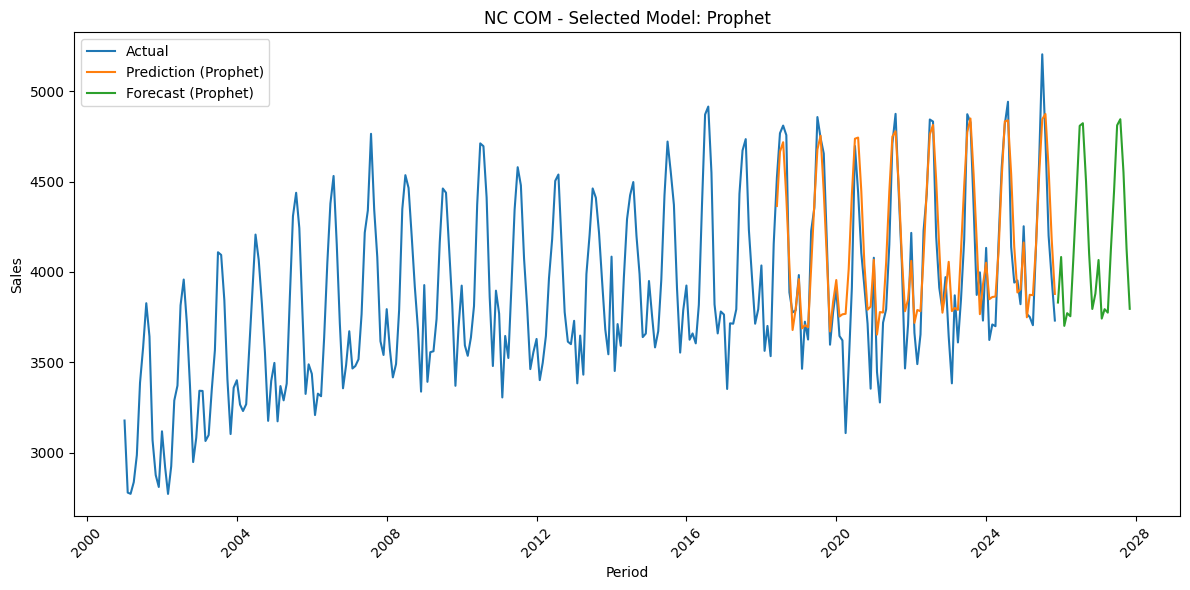

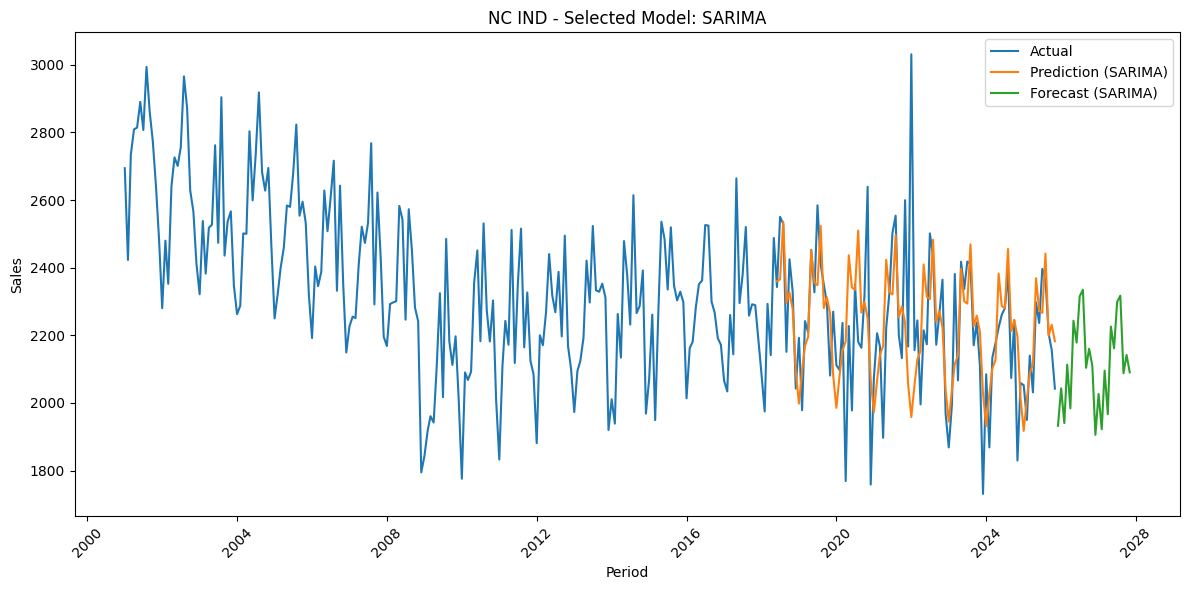

In [9]:
for sector in ["COM", "IND"]:
    plot_df = final_forecast_df[final_forecast_df["sector_type"] == sector].copy()
    selected_model = plot_df["model_used"].dropna().iloc[0]

    actual_df = plot_df[plot_df["data_label"] == "Actual"]
    test_df = plot_df[plot_df["data_label"] == "Predicted"]
    forecast_df = plot_df[plot_df["data_label"] == "Forecast"]

    plt.figure(figsize=(12, 6))
    plt.plot(actual_df["period"], actual_df["actual_value"], label="Actual")
    plt.plot(test_df["period"], test_df["predicted_value"], label=f"Prediction ({selected_model})")
    plt.plot(forecast_df["period"], forecast_df["predicted_value"], label=f"Forecast ({selected_model})")
    plt.xlabel("Period")
    plt.ylabel("Sales")
    plt.title(f"{stateid} {sector} - Selected Model: {selected_model}")
    plt.legend()
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

In [10]:
final_forecast_df.to_csv("../data/optimized_model.csv", index=False)